# Primer Vistazo

![](images/img1.png)

![](images/img2.png)

![](images/img3.png)

![](images/img4.png)


In [1]:
import pandas as pd
from unidecode import unidecode
from wordcloud import WordCloud
from nltk.corpus import stopwords
from collections import Counter
import re
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('data_dile.csv')

ModuleNotFoundError: No module named 'unidecode'

In [2]:
df = (df.drop_duplicates(subset='text'))

In [3]:
df['text_clean'] = (
    df['text']
    .str.replace(r'@\w+', '', regex=True)        # elimina menciones @
    .str.replace(r'http\S+', '', regex=True)     # elimina URLs que empiezan por http/https
    .str.replace(r'\s+', ' ', regex=True)        # normaliza espacios
    .str.strip()                                 # quita espacios extremos
)



In [4]:

list_of_tweets = []
for text_clean in df['text_clean']:
    complete_clean = unidecode(text_clean.lower())
    list_of_tweets.append(complete_clean)

In [5]:
stop_words = set()
stop_words.update([
    'a', 'de', 'https', 'http', 'y', 'e', 'el', 'den', 'por', 'ni', 'eso', 'que', 'con', 've', '1', 'lo', 'la', 'los', 'estan', 'no', 'le', 'se'
     ,'es', 'como','su', 'va', 'del','en', 'esta', 'ya', 'van', 'todo', 'para', 'mas', 'les', 'esto', 'sus', 'sin','o', 'ese', 'ahora', 'pero',
     'ello', 'porque', 'un', 'si', 'al', 'que', 'las', 'q', 'ellos', 'ahi', 'era','nada', 'nos', 'una', 'este', 'solo'])

In [6]:
text_all = " ".join(list_of_tweets)
from wordcloud import WordCloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=stop_words,
    collocations=False,   # evita palabras pegadas
    max_words=200
).generate(text_all)


## Nube de palabras

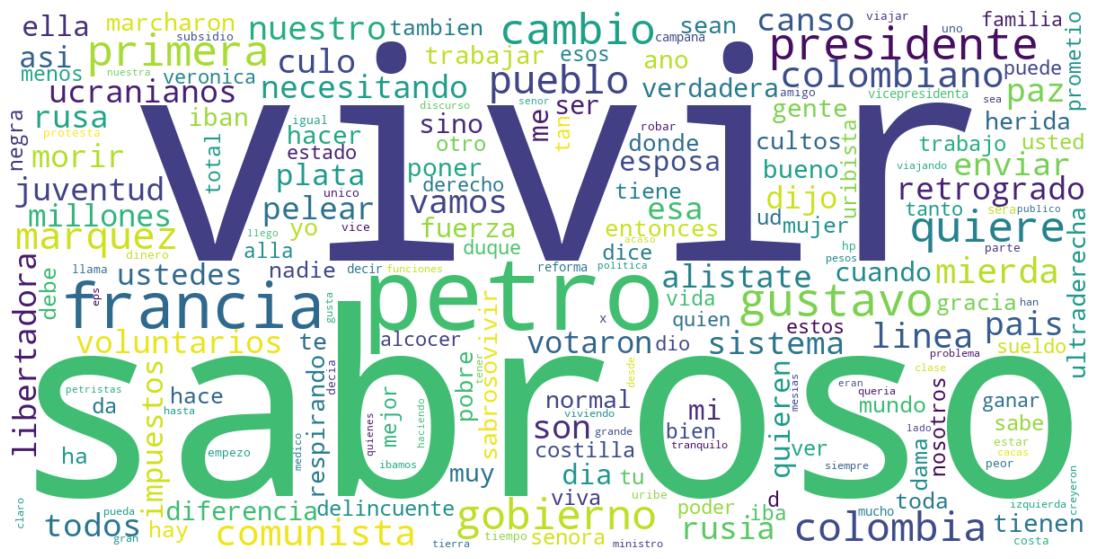

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [8]:
malas_palabras = [
    # Ideológicas / descalificación política
    "comunista",
    "ultraderecha",
    "retrogrado",
    "delincuente",
    "corrupto",

    # Emocionales / valorativas
    "cansó",
    "mierda",
    "culo",
    #"pobre",
    "solo",

    # Conflicto / violencia
    #"guerra",
    #"pelear",
    #"morir",
    #"herida",
    "rusia",

    # Socioeconómicas (en tono crítico)
    "impuestos",
    "plata",
    "necesitando",
    "millones"
]


In [9]:
words = re.findall(r'\b[a-záéíóúñü]+\b', text_all)

In [10]:
words = [w for w in words if w not in stop_words]
word_freq = Counter(words)

In [11]:

df_words = (
    pd.DataFrame(word_freq.items(), columns=['word', 'count'])
      .sort_values('count', ascending=False)
      .head(20)
)

## Conteo por Barras

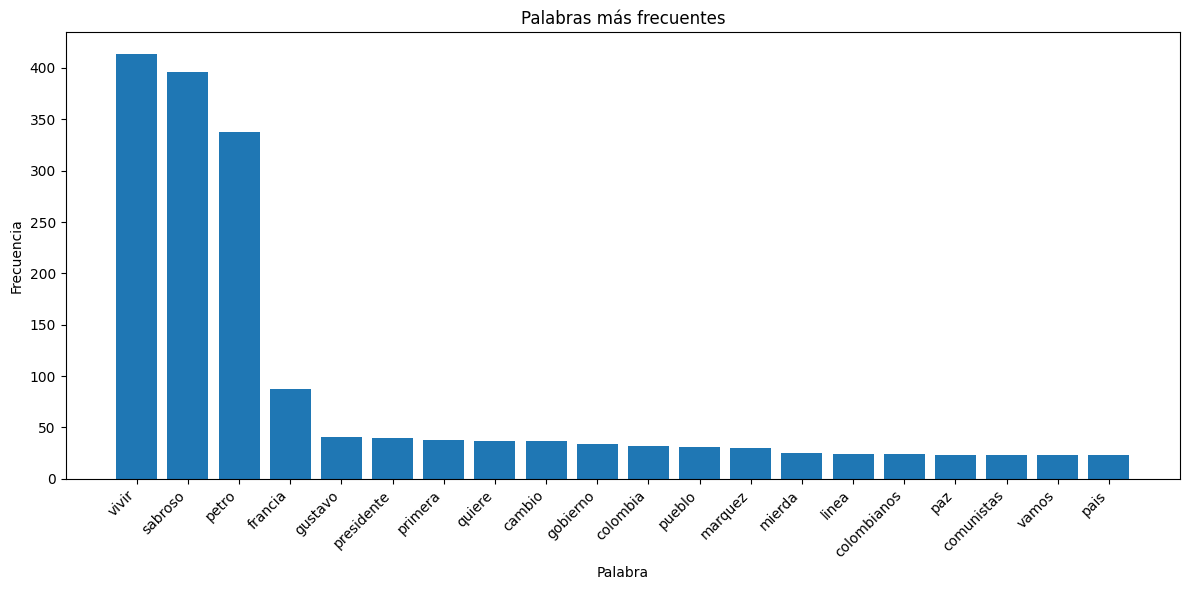

In [12]:
plt.figure(figsize=(12, 6))
plt.bar(df_words['word'], df_words['count'])
plt.xticks(rotation=45, ha='right')
plt.title("Palabras más frecuentes")
plt.ylabel("Frecuencia")
plt.xlabel("Palabra")
plt.tight_layout()
plt.show()


## Posibilidad de vigilar la distribucion de las connotaciones por localidad


![](images/img5.png)

Debido a que esto es texto libre se podria hacer un barrido seleccionando las ciudades mas importantes. Por tanto, se mostraria la distribución de los 'tipos' de comentarios por zonas principales y las demás.

![](images/img6.png)

Algo como esto, donde GX sea una zona seleccionada y el 'Si'-'No' puede ser cambiado por proporcion de comentarios negativos y positivos.


In [14]:
df_excel = pd.read_excel('data.xlsx', sheet_name='Contributors')

### lugares sin ninguna limpieza

In [20]:
df_excel.Location.value_counts()

Location
Colombia                     20
Bogotá, D.C., Colombia       17
Medellín, Colombia            6
Bogotá, Colombia              5
Montería, Colombia            3
                             ..
El mejor lugar del mundo      1
Cali                          1
Valle del Cauca, Colombia     1
In my shoes                   1
Villavicencio, Meta           1
Name: count, Length: 99, dtype: int64

In [30]:
mask = df_excel['Location'].str.lower() .str.contains(r'bogo', case=False, na=False, regex=True)
mask.sum()


np.int64(39)

Bogotá aparece 39 veces ~~ 39/300 = alrededor del 13% de los mensajes pertencen a bogotá.

### Se podría hacer lo mismo por las fechas